# ML MODEL MULTICLASS CLASSIFICATION MODEL

In [15]:
"""
1.2b ML Model — Multi-Class Classification (4 Classes)
=======================================================
Predicts the magnitude of tomorrow's price movement:
- Big Fall, Small Fall, Small Rise, Big Rise
"""

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────
PROCESSED_DIR = "../data/processed"
MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Features ───────────────────────────────────────────────────────
FEATURE_COLS = [
    # Original
    "Returns", "SMA_5", "SMA_20", "Volatility_5", "Volatility_20",
    "Volume_Change", "RSI_14", "Price_Range",
    # New
    "MACD", "MACD_Signal", "MACD_Hist",
    "BB_Width", "BB_Position",
    "Momentum_10", "Momentum_20",
    "ATR_Ratio",
    "Return_Lag1", "Return_Lag2", "Return_Lag3", "Return_Lag5",
    "Volume_Ratio",
    "DayOfWeek",
    "Dist_SMA_5", "Dist_SMA_20",
]

# ── Target ─────────────────────────────────────────────────────────
TARGET = "Target_Multi"
CLASS_NAMES = ["Big Fall", "Small Fall", "Small Rise", "Big Rise"]
MODEL_SUFFIX = "multi"

TICKERS = ["AMZN", "AAPL", "MSFT", "GOOG", "TSLA"]

print("✓ Multi-Class Classification Setup Complete")
print(f"  Target: {TARGET}")
print(f"  Classes: {CLASS_NAMES}")

✓ Multi-Class Classification Setup Complete
  Target: Target_Multi
  Classes: ['Big Fall', 'Small Fall', 'Small Rise', 'Big Rise']


LOAD DATA

In [16]:
def load_data(ticker: str) -> tuple:
    """Load data for multi-class classification."""
    
    path = f"{PROCESSED_DIR}/{ticker.lower()}_processed.csv"
    df = pd.read_csv(path, parse_dates=["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    df = df.dropna(subset=FEATURE_COLS + [TARGET])
    
    X = df[FEATURE_COLS]
    y = df[TARGET].astype(int)
    
    split_idx = int(len(df) * 0.7)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    print(f"Loaded {ticker}: {len(df)} rows")
    print(f"  Train: {len(X_train)} | Test: {len(X_test)}")
    print(f"  Class distribution: {dict(y_train.value_counts().sort_index())}")
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data("AMZN")

Loaded AMZN: 1217 rows
  Train: 851 | Test: 366
  Class distribution: {0: np.int64(245), 1: np.int64(169), 2: np.int64(178), 3: np.int64(259)}


DEFINE MODELS

In [17]:
def get_models() -> dict:
    """
    Models optimized for MULTI-CLASS classification.
    
    Notes:
    - Tree-based models often work better for multi-class
    - More estimators help distinguish between 4 classes
    - Using 'f1_macro' as main metric (handles imbalance)
    """
    
    return {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                solver="lbfgs",
                max_iter=2000,             # More iterations for 4 classes
                class_weight="balanced",
                random_state=42
            ))
        ]),
        
        "Random Forest": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(
                n_estimators=300,          # More trees for multi-class
                max_depth=12,              # Deeper for more complexity
                min_samples_split=5,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            ))
        ]),
        
        "Gradient Boosting": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", GradientBoostingClassifier(
                n_estimators=200,          # More boosting rounds
                max_depth=6,               # Deeper trees
                learning_rate=0.08,        # Slightly lower LR
                subsample=0.8,
                random_state=42
            ))
        ]),
        
        "XGBoost": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", XGBClassifier(
                n_estimators=250,
                max_depth=7,
                learning_rate=0.08,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                use_label_encoder=False,
                eval_metric="mlogloss",    # Multi-class log loss
                verbosity=0
            ))
        ]),
    }

print("Multi-Class Models:", list(get_models().keys()))

Multi-Class Models: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']


COMPARE MODELS

In [18]:
def compare_models(X_train, X_test, y_train, y_test) -> tuple:
    """Train and evaluate all models for multi-class classification."""
    
    models = get_models()
    results = []
    trained_models = {}
    
    print("Training Multi-Class Models...")
    print("-" * 65)
    
    for name, pipeline in models.items():
        pipeline.fit(X_train, y_train)
        trained_models[name] = pipeline
        
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average="macro")
        f1_weighted = f1_score(y_test, y_pred, average="weighted")
        
        try:
            auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
        except:
            auc = np.nan
        
        results.append({
            "Model": name,
            "Accuracy": round(acc, 4),
            "F1 Macro": round(f1_macro, 4),
            "F1 Weighted": round(f1_weighted, 4),
            "AUC (OvR)": round(auc, 4) if not np.isnan(auc) else "N/A"
        })
        
        print(f"{name:25s} | Acc: {acc:.4f} | F1 Macro: {f1_macro:.4f}")
    
    print("-" * 65)
    
    comparison_df = pd.DataFrame(results).sort_values("F1 Macro", ascending=False)
    return comparison_df, trained_models

comparison, trained_models = compare_models(X_train, X_test, y_train, y_test)
comparison

Training Multi-Class Models...
-----------------------------------------------------------------
Logistic Regression       | Acc: 0.2240 | F1 Macro: 0.1935
Random Forest             | Acc: 0.2350 | F1 Macro: 0.2307
Gradient Boosting         | Acc: 0.2377 | F1 Macro: 0.2215
XGBoost                   | Acc: 0.2377 | F1 Macro: 0.2203
-----------------------------------------------------------------


,Model,Accuracy,F1 Macro,F1 Weighted,AUC (OvR)
1,Random Forest,0.2350,0.2307,0.2286,0.5013
2,Gradient Boosting,0.2377,0.2215,0.2211,0.4962
3,XGBoost,0.2377,0.2203,0.2215,0.4993
0,Logistic Regression,0.2240,0.1935,0.1915,0.4869


CONFUSION MATRIX

Best Model: Random Forest



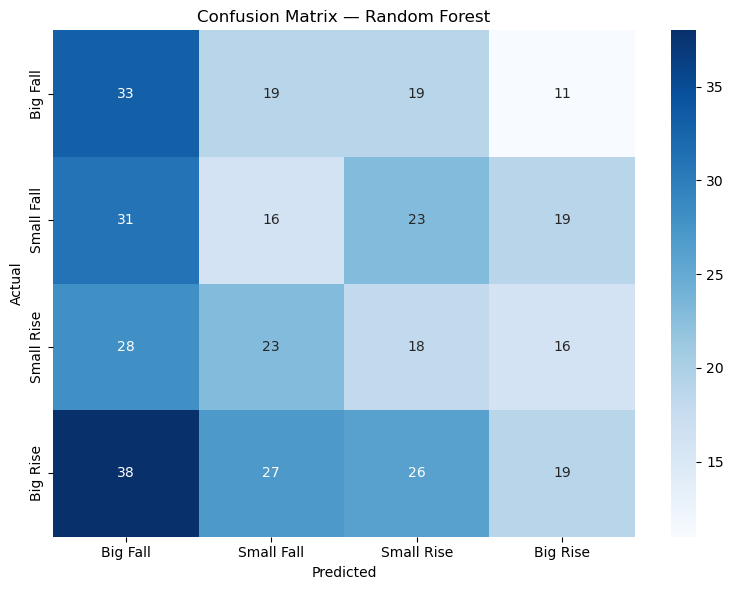

              precision    recall  f1-score   support

    Big Fall       0.25      0.40      0.31        82
  Small Fall       0.19      0.18      0.18        89
  Small Rise       0.21      0.21      0.21        85
    Big Rise       0.29      0.17      0.22       110

    accuracy                           0.23       366
   macro avg       0.24      0.24      0.23       366
weighted avg       0.24      0.23      0.23       366



In [19]:
def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

best_name = comparison.iloc[0]["Model"]
best_model = trained_models[best_name]
y_pred = best_model.predict(X_test)

print(f"Best Model: {best_name}\n")
plot_confusion_matrix(y_test, y_pred, best_name)

HYPERPARAMETER TUNING

In [20]:
def tune_model(model_name: str, X_train, y_train):
    """Tune hyperparameters for multi-class classification."""
    
    # Parameter grids optimized for multi-class
    param_grids = {
        "Logistic Regression": {
            "clf__C": [0.01, 0.1, 1, 10],
        },
        "Random Forest": {
            "clf__n_estimators": [200, 300, 400],
            "clf__max_depth": [8, 12, 15],
            "clf__min_samples_split": [3, 5, 10],
        },
        "Gradient Boosting": {
            "clf__n_estimators": [150, 200, 250],
            "clf__max_depth": [4, 6, 8],
            "clf__learning_rate": [0.05, 0.08, 0.1],
        },
        "XGBoost": {
            "clf__n_estimators": [200, 300],
            "clf__max_depth": [5, 7, 9],
            "clf__learning_rate": [0.05, 0.08],
        },
    }
    
    if model_name not in param_grids:
        return None, None, None
    
    pipeline = get_models()[model_name]
    param_grid = param_grids[model_name]
    
    print(f"Tuning {model_name}...")
    
    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=TimeSeriesSplit(n_splits=5),
        scoring="f1_macro",  # Multi-class uses F1 Macro
        n_jobs=-1,
        verbose=0
    )
    
    grid.fit(X_train, y_train)
    
    print(f"  Best params: {grid.best_params_}")
    print(f"  Best CV F1 Macro: {grid.best_score_:.4f}\n")
    
    return grid.best_estimator_, grid.best_params_, grid.best_score_

top_2 = comparison.head(2)["Model"].tolist()
tuned_models = {}

for name in top_2:
    best_pipe, best_params, best_score = tune_model(name, X_train, y_train)
    if best_pipe:
        tuned_models[name] = {"pipeline": best_pipe, "params": best_params, "cv_score": best_score}

Tuning Random Forest...
  Best params: {'clf__max_depth': 15, 'clf__min_samples_split': 3, 'clf__n_estimators': 300}
  Best CV F1 Macro: 0.2136

Tuning Gradient Boosting...
  Best params: {'clf__learning_rate': 0.08, 'clf__max_depth': 8, 'clf__n_estimators': 250}
  Best CV F1 Macro: 0.2429



EVALUATE TUNED MODELS

In [21]:
def evaluate_tuned(tuned_models, X_test, y_test) -> pd.DataFrame:
    """Evaluate tuned models on test set."""
    
    results = []
    
    for name, data in tuned_models.items():
        pipeline = data["pipeline"]
        y_pred = pipeline.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average="macro")
        f1_weighted = f1_score(y_test, y_pred, average="weighted")
        
        results.append({
            "Model": f"{name} (Tuned)",
            "Accuracy": round(acc, 4),
            "F1 Macro": round(f1_macro, 4),
            "F1 Weighted": round(f1_weighted, 4),
        })
        
        print(f"{name} (Tuned): Acc={acc:.4f}, F1 Macro={f1_macro:.4f}")
    
    return pd.DataFrame(results)

tuned_results = evaluate_tuned(tuned_models, X_test, y_test)
tuned_results

Random Forest (Tuned): Acc=0.2350, F1 Macro=0.2315
Gradient Boosting (Tuned): Acc=0.2377, F1 Macro=0.2252


,Model,Accuracy,F1 Macro,F1 Weighted
0,Random Forest (Tuned),0.2350,0.2315,0.2299
1,Gradient Boosting (Tuned),0.2377,0.2252,0.2243


CREATE ENSEMBLE

In [22]:
def create_ensemble(X_train, y_train, X_test, y_test):
    """
    Create ensemble optimized for multi-class classification.
    
    Uses more estimators and deeper trees than binary version
    to capture the complexity of 4 classes.
    """
    
    print("Creating Multi-Class Ensemble...")
    
    ensemble = VotingClassifier(
        estimators=[
            ("lr", Pipeline([
                ("scaler", StandardScaler()),
                ("clf", LogisticRegression(
                    max_iter=2000, 
                    class_weight="balanced", 
                    random_state=42
                ))
            ])),
            ("rf", Pipeline([
                ("scaler", StandardScaler()),
                ("clf", RandomForestClassifier(
                    n_estimators=300, 
                    max_depth=12, 
                    min_samples_leaf=3,
                    class_weight="balanced", 
                    random_state=42,
                    n_jobs=-1
                ))
            ])),
            ("gb", Pipeline([
                ("scaler", StandardScaler()),
                ("clf", GradientBoostingClassifier(
                    n_estimators=200, 
                    max_depth=6,
                    learning_rate=0.08,
                    subsample=0.8,
                    random_state=42
                ))
            ])),
            ("xgb", Pipeline([
                ("scaler", StandardScaler()),
                ("clf", XGBClassifier(
                    n_estimators=250, 
                    max_depth=7,
                    learning_rate=0.08,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=42,
                    use_label_encoder=False, 
                    eval_metric="mlogloss", 
                    verbosity=0
                ))
            ])),
        ],
        voting="soft",
        n_jobs=-1
    )
    
    ensemble.fit(X_train, y_train)
    
    y_pred = ensemble.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    
    print(f"Ensemble: Acc={acc:.4f}, F1 Macro={f1_macro:.4f}, F1 Weighted={f1_weighted:.4f}")
    
    return ensemble, {
        "Accuracy": acc, 
        "F1 Macro": f1_macro, 
        "F1 Weighted": f1_weighted
    }

ensemble, ensemble_metrics = create_ensemble(X_train, y_train, X_test, y_test)

Creating Multi-Class Ensemble...
Ensemble: Acc=0.2268, F1 Macro=0.2112, F1 Weighted=0.2096


SELECT BEST AND EXPORT

In [23]:
def select_and_export(ticker, trained_models, tuned_models, ensemble, ensemble_metrics, X_test, y_test):
    """
    Select best multi-class model based on F1 Macro and export.
    
    F1 Macro is used because:
    - It treats all 4 classes equally
    - It handles class imbalance better than accuracy
    """
    
    print(f"\n{'='*55}")
    print(f"FINAL SELECTION — {ticker} (Multi-Class)")
    print(f"{'='*55}")
    
    candidates = []
    
    # Base models
    for name, pipeline in trained_models.items():
        y_pred = pipeline.predict(X_test)
        f1 = f1_score(y_test, y_pred, average="macro")
        candidates.append({
            "name": name, 
            "pipeline": pipeline, 
            "f1_macro": f1, 
            "type": "Base"
        })
    
    # Tuned models
    for name, data in tuned_models.items():
        y_pred = data["pipeline"].predict(X_test)
        f1 = f1_score(y_test, y_pred, average="macro")
        candidates.append({
            "name": f"{name} (Tuned)", 
            "pipeline": data["pipeline"], 
            "f1_macro": f1, 
            "type": "Tuned"
        })
    
    # Ensemble
    candidates.append({
        "name": "Ensemble", 
        "pipeline": ensemble, 
        "f1_macro": ensemble_metrics["F1 Macro"], 
        "type": "Ensemble"
    })
    
    # Sort by F1 Macro (descending)
    candidates.sort(key=lambda x: x["f1_macro"], reverse=True)
    
    # Print ranking
    print("\nRanking (by F1 Macro):")
    print("-" * 45)
    for i, c in enumerate(candidates, 1):
        marker = "👑" if i == 1 else "  "
        print(f"{marker} {i}. {c['name']:30s} F1={c['f1_macro']:.4f} ({c['type']})")
    
    # Export best
    best = candidates[0]
    
    model_path = f"{MODELS_DIR}/model_{ticker}_{MODEL_SUFFIX}.joblib"
    features_path = f"{MODELS_DIR}/features_{ticker}_{MODEL_SUFFIX}.txt"
    
    joblib.dump(best["pipeline"], model_path)
    with open(features_path, "w") as f:
        f.write("\n".join(FEATURE_COLS))
    
    print(f"\n✓ Best Model: {best['name']}")
    print(f"✓ F1 Macro: {best['f1_macro']:.4f}")
    print(f"✓ Exported: {model_path}")
    
    return best

# Select and export for AMZN
best = select_and_export(
    "AMZN", 
    trained_models, 
    tuned_models, 
    ensemble, 
    ensemble_metrics, 
    X_test, 
    y_test
)


FINAL SELECTION — AMZN (Multi-Class)

Ranking (by F1 Macro):
---------------------------------------------
👑 1. Random Forest (Tuned)          F1=0.2315 (Tuned)
   2. Random Forest                  F1=0.2307 (Base)
   3. Gradient Boosting (Tuned)      F1=0.2252 (Tuned)
   4. Gradient Boosting              F1=0.2215 (Base)
   5. XGBoost                        F1=0.2203 (Base)
   6. Ensemble                       F1=0.2112 (Ensemble)
   7. Logistic Regression            F1=0.1935 (Base)

✓ Best Model: Random Forest (Tuned)
✓ F1 Macro: 0.2315
✓ Exported: ../models/model_AMZN_multi.joblib


RUN FOR AL TICKERS

In [24]:
def process_ticker(ticker: str) -> dict:
    """Full pipeline for one ticker."""
    
    print(f"\n{'#'*55}")
    print(f"# {ticker} — Multi-Class Classification")
    print(f"{'#'*55}")
    
    # Load data
    X_tr, X_te, y_tr, y_te = load_data(ticker)
    
    # Compare base models
    comp, trained = compare_models(X_tr, X_te, y_tr, y_te)
    
    # Tune top 2 models
    top_2 = comp.head(2)["Model"].tolist()
    tuned = {}
    for name in top_2:
        pipe, params, score = tune_model(name, X_tr, y_tr)
        if pipe:
            tuned[name] = {
                "pipeline": pipe, 
                "params": params, 
                "cv_score": score
            }
    
    # Create ensemble
    ens, ens_m = create_ensemble(X_tr, y_tr, X_te, y_te)
    
    # Select and export best
    best = select_and_export(ticker, trained, tuned, ens, ens_m, X_te, y_te)
    
    return {
        "Ticker": ticker,
        "Best Model": best["name"],
        "F1 Macro": round(best["f1_macro"], 4)
    }


def process_all_tickers(tickers: list) -> pd.DataFrame:
    """Train multi-class models for all tickers."""
    
    summary = []
    
    for ticker in tickers:
        try:
            result = process_ticker(ticker)
            summary.append(result)
        except Exception as e:
            print(f"ERROR processing {ticker}: {e}")
            summary.append({
                "Ticker": ticker,
                "Best Model": "ERROR",
                "F1 Macro": np.nan
            })
    
    return pd.DataFrame(summary)


# Run for all tickers
final_summary = process_all_tickers(TICKERS)
print("\n" + "="*55)
print("MULTI-CLASS CLASSIFICATION SUMMARY")
print("="*55)
final_summary


#######################################################
# AMZN — Multi-Class Classification
#######################################################
Loaded AMZN: 1217 rows
  Train: 851 | Test: 366
  Class distribution: {0: np.int64(245), 1: np.int64(169), 2: np.int64(178), 3: np.int64(259)}
Training Multi-Class Models...
-----------------------------------------------------------------
Logistic Regression       | Acc: 0.2240 | F1 Macro: 0.1935
Random Forest             | Acc: 0.2350 | F1 Macro: 0.2307
Gradient Boosting         | Acc: 0.2377 | F1 Macro: 0.2215
XGBoost                   | Acc: 0.2377 | F1 Macro: 0.2203
-----------------------------------------------------------------
Tuning Random Forest...
  Best params: {'clf__max_depth': 15, 'clf__min_samples_split': 3, 'clf__n_estimators': 300}
  Best CV F1 Macro: 0.2136

Tuning Gradient Boosting...
  Best params: {'clf__learning_rate': 0.08, 'clf__max_depth': 8, 'clf__n_estimators': 250}
  Best CV F1 Macro: 0.2429

Creating Multi-Cl

,Ticker,Best Model,F1 Macro
0,AMZN,Random Forest (Tuned),0.2315
1,AAPL,Random Forest,0.2338
2,MSFT,XGBoost,0.2523
3,GOOG,Ensemble,0.2442
4,TSLA,Logistic Regression,0.2982


VERIFY FOR ALL TICKERS

In [27]:
print("Multi-Class Models Exported:")
print("-" * 45)

all_ok = True
for ticker in TICKERS:
    model_path = f"{MODELS_DIR}/model_{ticker}_{MODEL_SUFFIX}.joblib"
    features_path = f"{MODELS_DIR}/features_{ticker}_{MODEL_SUFFIX}.txt"
    
    model_exists = os.path.exists(model_path)
    features_exists = os.path.exists(features_path)
    
    if model_exists and features_exists:
        # Load and verify
        model = joblib.load(model_path)
        with open(features_path) as f:
            features = [l.strip() for l in f if l.strip()]
        
        status = "✓"
        info = f"{len(features)} features"
    else:
        status = "✗"
        info = "MISSING"
        all_ok = False
    
    print(f"{status} {ticker}_multi: {info}")

print("-" * 45)
if all_ok:
    print("✓ All multi-class models exported successfully!")
else:
    print("✗ Some models are missing. Re-run the notebook.")

Multi-Class Models Exported:
---------------------------------------------
✓ AMZN_multi: 24 features
✓ AAPL_multi: 24 features
✓ MSFT_multi: 24 features
✓ GOOG_multi: 24 features
✓ TSLA_multi: 24 features
---------------------------------------------
✓ All multi-class models exported successfully!


FEATURE IMPORTANCE


AMZN:
Loaded model type: Pipeline
Classifier type: RandomForestClassifier


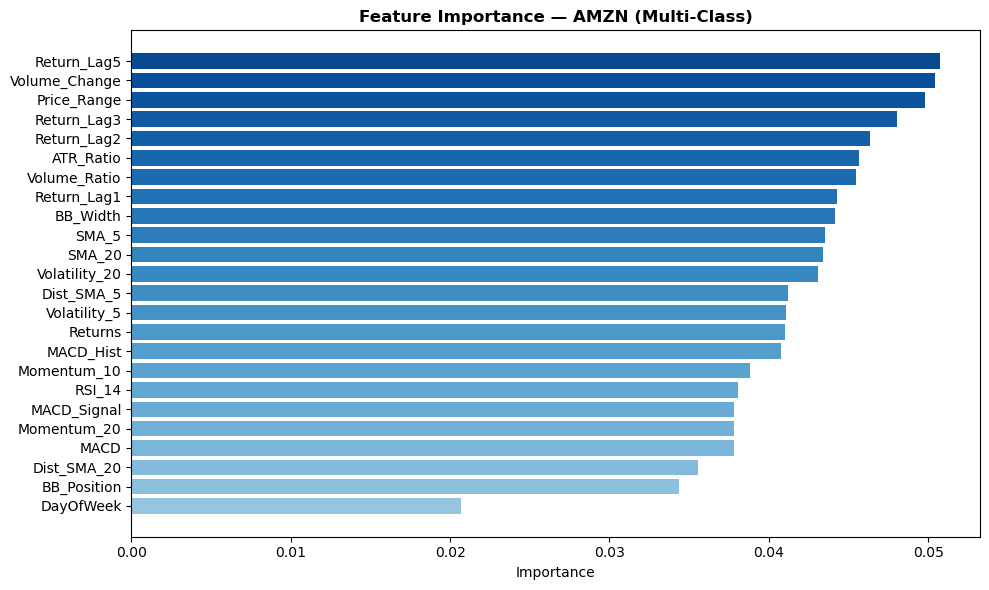


AAPL:
Loaded model type: Pipeline
Classifier type: RandomForestClassifier


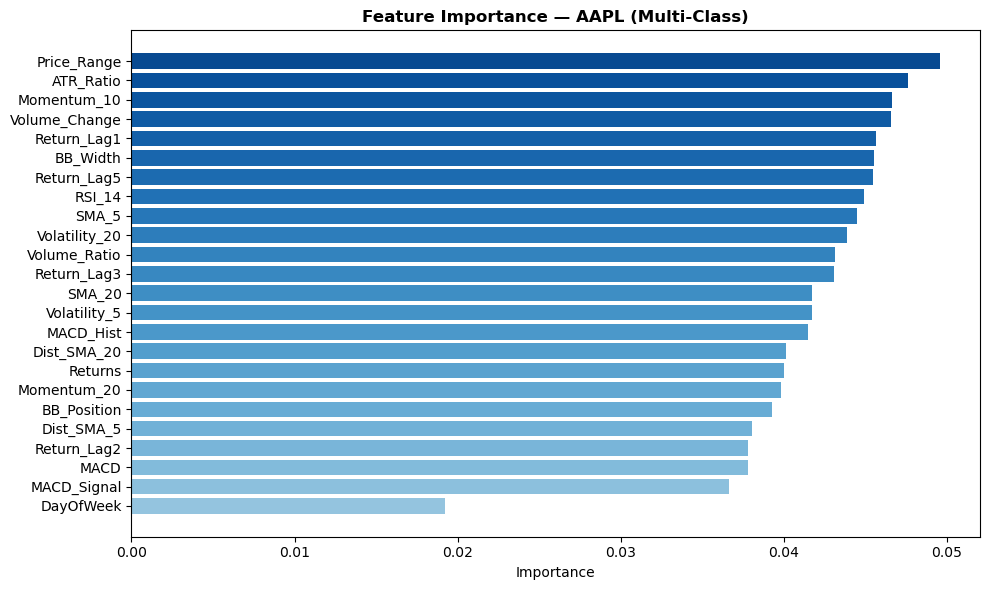


MSFT:
Loaded model type: Pipeline
Classifier type: XGBClassifier


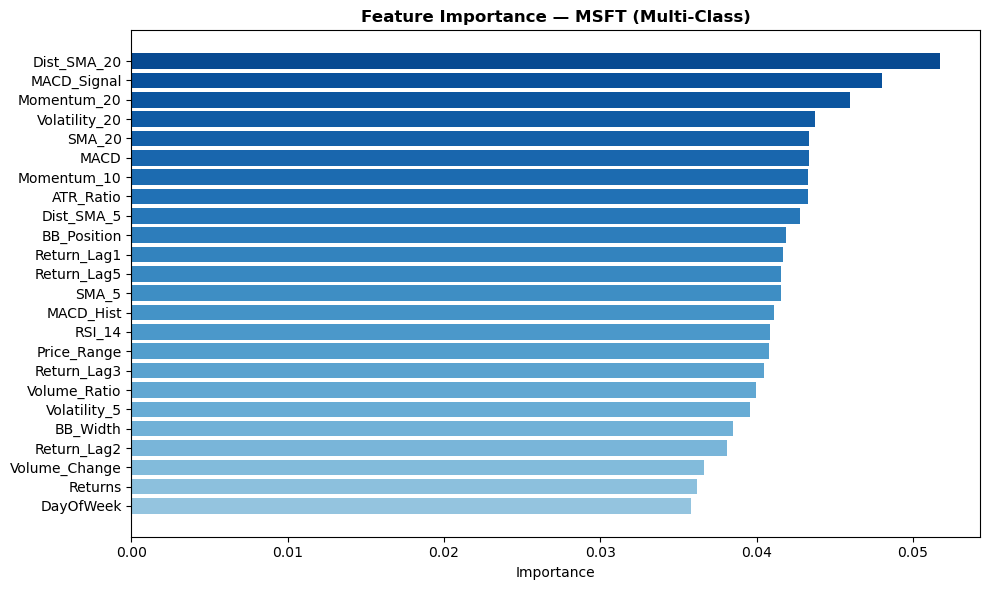


GOOG:
Loaded model type: VotingClassifier
Raw VotingClassifier → extracting RF importance


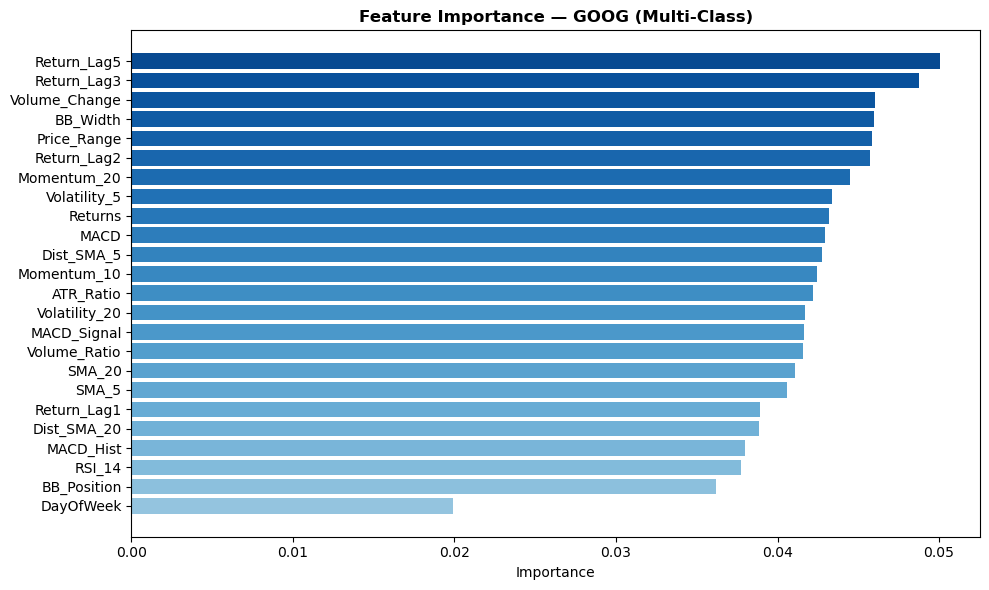


TSLA:
Loaded model type: Pipeline
Classifier type: LogisticRegression


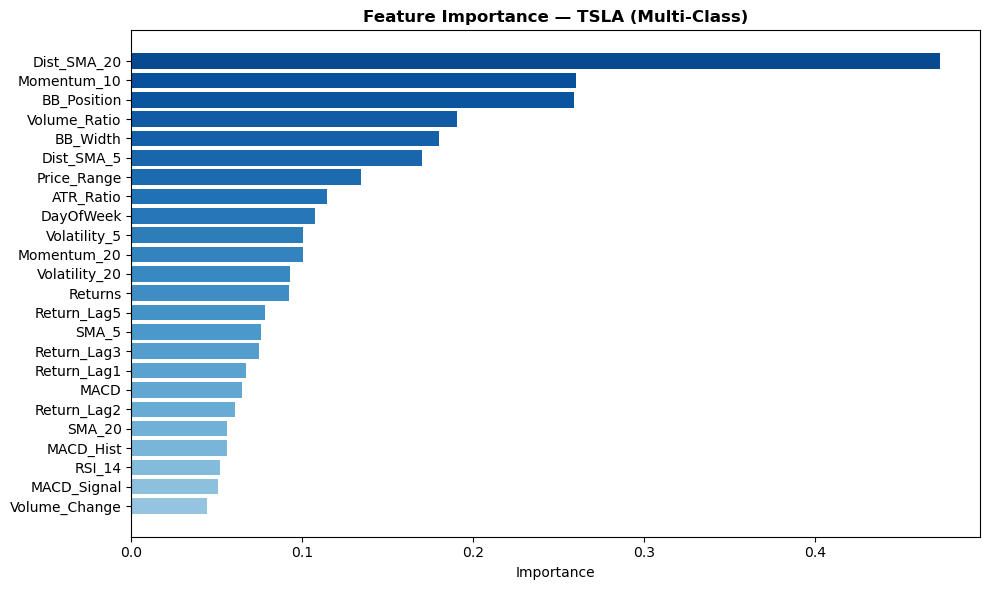

In [45]:
from sklearn.ensemble import VotingClassifier

def plot_feature_importance(ticker: str):
    """Plot feature importance for the best model."""
    
    model_path = f"{MODELS_DIR}/model_{ticker}_{MODEL_SUFFIX}.joblib"
    features_path = f"{MODELS_DIR}/features_{ticker}_{MODEL_SUFFIX}.txt"
    
    model = joblib.load(model_path)
    with open(features_path) as f:
        features = [l.strip() for l in f if l.strip()]
    
    model_type = type(model).__name__
    print(f"Loaded model type: {model_type}")
    
    # Case 1: It's a Pipeline
    if hasattr(model, "named_steps"):
        clf = model.named_steps.get("clf")
        clf_type = type(clf).__name__
        print(f"Classifier type: {clf_type}")
        
        if isinstance(clf, VotingClassifier):
            print("VotingClassifier → extracting RF importance")
            rf_pipeline = clf.estimators_[1]
            importances = rf_pipeline.named_steps["clf"].feature_importances_
        elif hasattr(clf, "feature_importances_"):
            # RandomForest, GradientBoosting, XGBoost, etc.
            importances = clf.feature_importances_
        elif hasattr(clf, "coef_"):
            # LogisticRegression, SVM, etc.
            importances = np.abs(clf.coef_).mean(axis=0)
        else:
            print(f"Cannot extract importance from {clf_type}")
            return
    
    # Case 2: Raw VotingClassifier (not wrapped in Pipeline)
    elif isinstance(model, VotingClassifier):
        print("Raw VotingClassifier → extracting RF importance")
        rf_pipeline = model.estimators_[1]
        importances = rf_pipeline.named_steps["clf"].feature_importances_
    
    else:
        print(f"Unknown model structure: {model_type}")
        return
    
    # Plot
    importance_df = pd.DataFrame({
        "Feature": features,
        "Importance": importances
    }).sort_values("Importance", ascending=True)
    
    plt.figure(figsize=(10, 6))
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(importance_df)))
    plt.barh(importance_df["Feature"], importance_df["Importance"], color=colors)
    plt.xlabel("Importance")
    plt.title(f"Feature Importance — {ticker} (Multi-Class)", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{MODELS_DIR}/feature_importance_{ticker}_multi.png", dpi=150)
    plt.show()
    
    return importance_df

# Test all tickers
for ticker in TICKERS:
    print(f"\n{ticker}:")
    plot_feature_importance(ticker)